In [1]:

# why multi-head is better than single-head ? 

# https://gemini.google.com/app/8720e969a2fcbae5
# The Averaging Bottleneck (Single Head)
# Representation Subspaces (Multi-Head)
# The Computational Equivalence

# too many heads:
#   Dot-product discriminability collapses: In a d_head-dimensional random projection, the variance of the dot product between two vectors scales with d_head, When d_head gets very small, there just isn't enough room for queries/keys to be pushed far apart in angle — random or near-random keys start looking similar to a query, so the softmax degenerates toward uniform, You get noise-induced averaging, which is the same symptom you were trying to escape (uniform attention), just caused by insufficient dimensionality instead of a forced single softmax.
#   Johnson–Lindenstrauss-style capacity limit. To keep pairwise angular relationships between N distinguishable concepts roughly preserved under a linear projection, you need roughly d_head = O(log N / ε²) dimensions. Below that, key vectors for genuinely different tokens start colliding in the projected space — the head physically cannot keep enough patterns separable   


# pay-off curve = inverted-U
# 
# performance
    # ^
    # |         ____________
    # |       /              \___
    # |      /                    \___
    # |     /                          \
    # |    /
    # |   /
    # +--+---------------------------------> h (num heads, d_head = d_model/h)
    #    1    few heads    "sweet spot"    many tiny heads
    #    (averaging       (diverse, still  (noisy dot products,
    #     bottleneck)      well-powered)    redundant/collapsing heads)
#  


# Multi-head splitting trades a combinatorial bottleneck (can't represent multiple relations at once) for a dimensionality/statistical 
# bottleneck (each relation is represented too weakly to be reliably distinguished). The optimum sits where you've captured most of the 
# useful "different relation types need different heads" benefit before dot-product signal-to-noise per head starts degrading — empirically, 
# that's around d_head ≈ 64–128 for typical model/vocab scales, largely independent of total model size.


#---
# implement YaRN for positinal encodings, QK norm

# MHA: num_query_heads == num_kv_heads
# GQA: 1 < num_kv_heads < num_query_heads and num_query_heads % num_kv_heads == 0
# MQA: num_kv_heads == 1


# TODO:

# line-by-line explaination of this script, weight init method used, RoPE rewrite, compute graph vis, tensor health check, attentino map vis
# make a report on: SHA/MQA/GQA/MHA performance/cost 
# report benchmark: cached vs. uncached decode latency as sequence length grows

In [ ]:
# TODO: 
# BatchLoader-> to binary np.memmap/single index tensor instead of a Python list comprehension,
#                validation func for validation testing

# 

In [1]:
import time
import json

# ! will NEED PyTorch version 2.5+ --> for scaled_dot_product_attention(enable_gqa=True)
import torch
import torch.nn as nn
from typing import Union
import torch.nn.functional as F
from dataclasses import dataclass
from typing import Optional, Tuple
from einops import rearrange, einsum

from model_config import ModelConfig
import training_engine as training_engine 
from tensor_tools import init_custom_weight, inspect_tensor
from inference_engine import advanced_inference, load_model_weights
from kv_cache import KV_cache


device = 'cuda' if torch.cuda.is_available() else 'cpu'

print(f"Device:         {device}")
print(f"PyTorch:        {torch.__version__}")

if torch.cuda.is_available():
    print(f"GPU:            {torch.cuda.get_device_name(0)}")
    print(f"CUDA version:   {torch.version.cuda}")

    print(f"device capability: {torch.cuda.get_device_capability()}")
    print(f"flash_attention_available: {torch.backends.cuda.is_flash_attention_available()}")


Device:         cuda
PyTorch:        2.8.0+cu129
GPU:            NVIDIA GeForce GTX 1660 Ti
CUDA version:   12.9
device capability: (7, 5)
flash_attention_available: False


In [2]:

configs = ModelConfig(

    model_name="level2_attention_models",
    tied_embeddings=False,  
    
    embed_dim=2**5,   # 32
    vocab_size=2**11,  # 2048
    num_layers=5,
    max_context_window=2**6,   # 64
    
    num_q_heads=2**0,  # 1 | 1   x   x    x
    num_kv_heads=2**0, # 1 | 1   1   2+   x
    
    max_training_batch_size=2**4,   # 16
    learning_rate=1e-3,

    rope_theta=10000.0, 

    mlp_to_embed_expand_factor= None,
    num_experts= None,
    num_experts_per_tkn=None,
   
    save_path="../models/level2_attention_models.pt",
    val_loss_history="../models/level2_attention_models_val_loss_history.txt"
)

print(configs)

ModelConfig(model_name='level2_attention_models', tied_embeddings=False, embed_dim=32, vocab_size=2048, num_layers=5, max_context_window=64, num_q_heads=1, num_kv_heads=1, max_training_batch_size=16, learning_rate=0.001, rope_theta=10000.0, mlp_to_embed_expand_factor=None, num_experts=None, num_experts_per_tkn=None, save_path='../models/level2_attention_models.pt', val_loss_history='../models/level2_attention_models_val_loss_history.txt')


In [3]:
class RotaryEmbedding(nn.Module):

    def __init__(self, config:ModelConfig):
        super().__init__()

        base     = config.rope_theta
        head_dim = config.embed_dim // config.num_q_heads

        # TODO: Compute the frequencies in fp32 explicitly.

        # shape: [head_dim // 2]
        inv_freq = 1.0 / (
            base ** (torch.arange(0, head_dim, 2).float() / head_dim)
        ).to(dtype=torch.float32)
        
        self.register_buffer("inv_freq", inv_freq, persistent=False)


    def forward(
            self,
            position_ids: torch.Tensor,   # [B, seq] or [seq]
            dtype= torch.float32,
        ) -> tuple[torch.Tensor, torch.Tensor]:
            """position_ids: [B, T] (or [T]) -> cos, sin of shape [B, 1, T, head_dim]"""

            if position_ids.dim() == 1:
                position_ids = position_ids.unsqueeze(0)          # [1, seq]


            # position_ids: [B, seq]  (integer)
            # inv_freq:     [head_dim//2]
            # freqs:        [B, seq, head_dim//2]
            freqs = torch.einsum(
                "bi,j->bij",
                position_ids.to(dtype=self.inv_freq.dtype),
                self.inv_freq,
            )

            emb = torch.cat((freqs, freqs), dim=-1) # [B, seq, head_dim]

            # broadcast over the head dimension → [B, 1, seq, head_dim]
            return emb.cos().to(dtype).unsqueeze(1), emb.sin().to(dtype).unsqueeze(1)


def rotate_half(x: torch.Tensor) -> torch.Tensor:
    x1, x2 = x.chunk(2, dim=-1)
    return torch.cat((-x2, x1), dim=-1)


def apply_rotary_pos_emb(
    q:   torch.Tensor,
    k:   torch.Tensor,
    cos: torch.Tensor,
    sin: torch.Tensor,
) -> Tuple[torch.Tensor, torch.Tensor]:
    
    cos = cos.to(device=q.device, dtype=q.dtype)
    sin = sin.to(device=q.device, dtype=q.dtype)

    q = (q * cos) + (rotate_half(q) * sin)
    k = (k * cos) + (rotate_half(k) * sin)
    return q, k

In [4]:
class Attention_SubBlock(nn.Module):

    def __init__(self, config:ModelConfig):
        super().__init__()

        self.embed_dim    = config.embed_dim
        self.num_q_heads  = config.num_q_heads
        self.num_kv_heads = config.num_kv_heads
        self.num_layers   = config.num_layers
        
        if self.embed_dim % self.num_q_heads != 0:
            raise ValueError("embed_dim must be divisible by num_q_heads")
        if self.num_q_heads % self.num_kv_heads != 0:
            raise ValueError("num_q_heads must be divisible by num_kv_heads")

        self.head_dim = self.embed_dim // self.num_q_heads
        self.q_dim    = self.num_q_heads * self.head_dim
        self.kv_dim   = self.num_kv_heads * self.head_dim

        # ONE matrix for Q, K and V: columns are [ q | k | v ]
        self.W_qkv = nn.Parameter(torch.empty(self.embed_dim, self.q_dim + 2 * self.kv_dim))
        self.W_o = nn.Parameter(torch.empty(self.q_dim, self.embed_dim))

        self.init_params()


    def init_params(self):

        q_end = self.q_dim
        k_end = q_end + self.kv_dim

        W_q = self.W_qkv[:, :q_end]
        W_k = self.W_qkv[:, q_end:k_end]
        W_v = self.W_qkv[:, k_end:]

        init_custom_weight(W_q, is_residual_output=False)
        init_custom_weight(W_k, is_residual_output=False)
        init_custom_weight(W_v, is_residual_output=False)

        # Residual output projection (scaled by depth)
        init_custom_weight(self.W_o, 
                           is_residual_output=True, 
                           num_layers=self.num_layers)



    def forward(
        self,
        x:   torch.Tensor,
        cos: torch.Tensor,          # [B, 1, seq, head_dim] – already computed
        sin: torch.Tensor,
        cache: Optional[KV_cache] = None,
        layer_idx: int = 0,
        
        lane_ids:  Optional[torch.Tensor] = None,
        attn_mask: Optional[torch.Tensor] = None,   # [B, 1, T, kv_len] bool, from cache.prepare()
   
    ) -> torch.Tensor:

        batch_size, seq_len, embed_dim = x.shape

        qkv = x @ self.W_qkv  # [B, T, q_dim + 2*kv_dim]
        q, k, v = qkv.split([self.q_dim, self.kv_dim, self.kv_dim], dim=-1)


        q = rearrange(q, 
                      "batch_size seq_len (num_q_heads head_dim)" 
                      " -> " 
                      "batch_size num_q_heads seq_len head_dim", 
                      num_q_heads=self.num_q_heads)
        
        k = rearrange(k, 
                      "batch_size seq_len (num_kv_heads head_dim)" 
                      " -> " 
                      "batch_size num_kv_heads seq_len head_dim",
                      num_kv_heads=self.num_kv_heads)
        
        v = rearrange(v, 
                      "batch_size seq_len (num_kv_heads head_dim)" 
                      " -> " 
                      "batch_size num_kv_heads seq_len head_dim",
                      num_kv_heads=self.num_kv_heads)


        q, k = apply_rotary_pos_emb(q, k, cos, sin)


        if cache is not None:
            k, v = cache.update(layer_idx, lane_ids, k, v)



        # The mask rule is that a query at absolute position p may attend to a key at 
        # absolute position a iff p - W < a <= p. The <= p part is causality, 
        # and the > p - W part is the sliding window. 
        out = F.scaled_dot_product_attention(
            q, k, v,
            attn_mask=attn_mask,
            is_causal=(attn_mask is None), # fast path only when no mask is given
            enable_gqa=(self.num_q_heads != self.num_kv_heads),
        )


        # Merge attention heads
        out = rearrange(
            out,
            "batch_size num_q_heads seq_len head_dim"
            " -> " 
            "batch_size seq_len (num_q_heads head_dim)",
        )


        return out @ self.W_o


In [5]:
class Transformer_Block(nn.Module):
    def __init__(self, config:ModelConfig):
        super().__init__()
        self.attention_sub_block = Attention_SubBlock(config)
        self.norm = nn.RMSNorm(config.embed_dim)


    def forward(
        self,
        x: torch.Tensor,
        cos: torch.Tensor,
        sin: torch.Tensor,
        cache: Optional[KV_cache] = None,
        layer_idx: int = 0,

        lane_ids =None, 
        attn_mask=None

    ) -> torch.Tensor:
        
        residual = x
        
        x = self.norm(x)

        x = self.attention_sub_block(
            x, 
            cos, 
            sin, 
            cache=cache, 
            layer_idx=layer_idx,
            lane_ids=lane_ids, 
            attn_mask=attn_mask,
        )

        return  x + residual


In [6]:
class Level2_Model(nn.Module):

    def __init__(self, config:ModelConfig):
        super().__init__()

        self.vocab_size = config.vocab_size
        self.embed_dim  = config.embed_dim  

        self.tied_embeddings = config.tied_embeddings      


        self.embed  = nn.Parameter(torch.empty(self.vocab_size, self.embed_dim))
        
        if not self.tied_embeddings:
            self.unembed = nn.Parameter(torch.empty(self.embed_dim, self.vocab_size))


        self.rotary = RotaryEmbedding(config)

        self.layers = nn.ModuleList([Transformer_Block(config) 
                                     for _ in range(config.num_layers)
                                    ])

        self.final_rms_norm = nn.RMSNorm(config.embed_dim)

        # self.unembed = nn.Parameter(torch.empty(self.embed_dim, self.vocab_size))

        self.init_params()



    def init_params(self):
        init_custom_weight(self.embed,   is_residual_output=False)
        
        if not self.tied_embeddings:
            init_custom_weight(self.unembed, is_residual_output=False)


    def forward(
            self, 
            input_ids: torch.Tensor, 
            cache: Optional[KV_cache] = None,
            lane_ids: Optional[torch.Tensor] = None,  # which cache lane each batch row uses
            attn_mask=None, # attn_mask only used without cache (tests)
    ) -> torch.Tensor:

        batch_size, seq_len = input_ids.shape

        device = input_ids.device # from the data, never a global
        # print('input_ids.device -> ', input_ids.device)

        # [batch_size, seq_len] -> [batch_size, seq_len, embed_dim]
        x = self.embed[input_ids] 



        if cache is None:
            position_ids = torch.arange(seq_len, device=device).expand(batch_size, -1)
            # attn_mask stays whatever the caller passed (None -> is_causal fast path)
        else:
            if lane_ids is None:
                lane_ids = torch.arange(batch_size, device=device)
            position_ids, attn_mask = cache.prepare(lane_ids, seq_len)


        cos, sin = self.rotary(position_ids, dtype=x.dtype)


        
        for i, layer in enumerate(self.layers):
                x = layer(x, 
                          cos, 
                          sin, 
                          cache=cache, 
                          layer_idx=i,
                          lane_ids=lane_ids,
                          attn_mask=attn_mask,
                        )        

        if cache is not None:
            cache.commit(lane_ids, seq_len) # once, after ALL layers


        x = self.final_rms_norm(x)


        if self.tied_embeddings:
            return x @ self.embed.T                    # [B, T, V]
        
        return x @ self.unembed
    

Step 0000 | train(avg) 7.6338 | val 7.6282 | val ppl 2055.44
Step 0050 | train(avg) 7.2361 | val 7.1967 | val ppl 1335.01
Step 0100 | train(avg) 6.9997 | val 6.9851 | val ppl 1080.41
Step 0150 | train(avg) 6.7687 | val 6.7191 | val ppl 828.07
Step 0200 | train(avg) 6.3728 | val 6.3132 | val ppl 551.81
Step 0250 | train(avg) 6.0245 | val 5.9692 | val ppl 391.19
Step 0300 | train(avg) 5.7296 | val 5.7047 | val ppl 300.27
Step 0350 | train(avg) 5.5255 | val 5.4965 | val ppl 243.85
Step 0400 | train(avg) 5.3669 | val 5.3175 | val ppl 203.87
Step 0450 | train(avg) 5.1989 | val 5.1788 | val ppl 177.48
Step 0500 | train(avg) 5.0963 | val 5.0614 | val ppl 157.81
Step 0550 | train(avg) 5.0337 | val 4.9760 | val ppl 144.89
Step 0600 | train(avg) 4.9107 | val 4.9007 | val ppl 134.38
Step 0650 | train(avg) 4.8112 | val 4.8233 | val ppl 124.38
Step 0700 | train(avg) 4.7718 | val 4.7555 | val ppl 116.23
Step 0750 | train(avg) 4.7903 | val 4.7103 | val ppl 111.08
Step 0800 | train(avg) 4.6721 | val 4

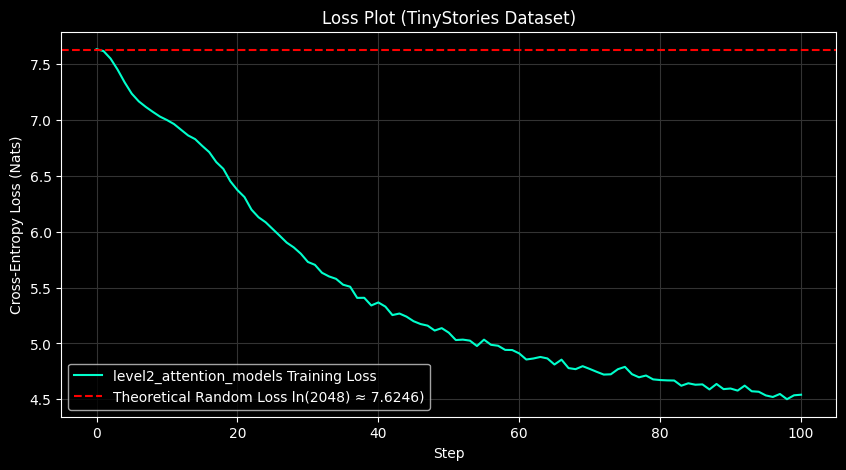

Loaded state_dict from ..\models\level2_attention_models.pt
Number of parameter tensors: 18
Number of parameters: 151,744

PARAMETER SUMMARY
embed: shape=(2048, 32), dtype=torch.float32, numel=65,536
unembed: shape=(32, 2048), dtype=torch.float32, numel=65,536
layers.0.attention_sub_block.W_qkv: shape=(32, 96), dtype=torch.float32, numel=3,072
layers.0.attention_sub_block.W_o: shape=(32, 32), dtype=torch.float32, numel=1,024
layers.0.norm.weight: shape=(32,), dtype=torch.float32, numel=32
layers.1.attention_sub_block.W_qkv: shape=(32, 96), dtype=torch.float32, numel=3,072
layers.1.attention_sub_block.W_o: shape=(32, 32), dtype=torch.float32, numel=1,024
layers.1.norm.weight: shape=(32,), dtype=torch.float32, numel=32
layers.2.attention_sub_block.W_qkv: shape=(32, 96), dtype=torch.float32, numel=3,072
layers.2.attention_sub_block.W_o: shape=(32, 32), dtype=torch.float32, numel=1,024
layers.2.norm.weight: shape=(32,), dtype=torch.float32, numel=32
layers.3.attention_sub_block.W_qkv: shap

In [7]:

model = Level2_Model(configs)


if torch.cuda.is_available():
    torch.cuda.synchronize()
start = time.time()


training_engine.train_and_save_model(model, configs, device, 1000)

training_engine.plot_loss_history(configs)

training_engine.inspect_weight_file(configs.save_path)


if torch.cuda.is_available():
    torch.cuda.synchronize()
total_time = time.time() - start
print("total_time -> ", total_time)



if torch.cuda.is_available():
    max_mem_bytes = torch.cuda.max_memory_allocated()
    max_mem_gb = max_mem_bytes / (1024 ** 3)
    print(f"Max memory allocated: {max_mem_gb:.2f} GB")


In [8]:

# Load the JSON file
with open("2048-tokenizer.json", "r", encoding="utf-8") as f:
    tokenizer_data = json.load(f)
eos_token_id = tokenizer_data.get("special_tokens", {}).get("<|endoftext|>")


model = load_model_weights(
    Level2_Model(configs),
    configs.save_path,
    device,
)

prompt_strs = [
    "write a story about",
    "write like a little boy that was angry",
    "write as a little boy that was happy,",
    "my name is ",
] 



results = advanced_inference(
    model=model, 
    configs=configs,
    prompt_strs=prompt_strs,
    device=device, 
    max_new_tokens=500,     # far beyond max_context_window=64: fine
    max_KV_lanes=2, 
    chunk_size=16, 
    eos_token_id=eos_token_id,
)

for r in results:
    print("---" * 20); print(r.text, f"[{r.finish_reason}]")

[INFO] Loaded weights from ..\models\level2_attention_models.pt (151,744 parameters)
------------------------------------------------------------
write a story about a spor tree.
"Let's school. I have a nest!"
"Yes, I want to help others and her party because he made the door and sand his friend, a little bird named Ben, Maybe it was flying some colorful car to them. They would go inside it, and they all lived happily ever after.
 [eos]
------------------------------------------------------------
write like a little boy that was angry. He decided to do it. She saw Lily on them to their mom, "Yes, I love you. I want to be friends." Mia said, “Bee! But I will be friends! But I should not be the best of their friends, Lily. Jane said, "Look at my friend!" But the cat and the dog was relly. After they got sad and said, "OK, Lily!" Sue was walking in the save and laughed his toy in is not to get it. The car was still so he had to take it.
"OK?" Lily said.
"Mom, can go home. Grandug is so pr

In [ ]:
# TODO: continue training from checkpoint, save opt state &...


# model = load_model_weights(
#     Level2_Model(configs),
#     configs.save_path,
#     device,
#     mode="train" #TODO
# )
